<a href="https://colab.research.google.com/github/Crisamack/Student-Perfomance/blob/main/Student_Perfomance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carregando os Dados

In [7]:
import pandas as pd

df = pd.read_csv('student_perfomance.csv')
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


# Entendendo a Estrutura do Dataset

In [10]:
# Tipos de Coluna; Valores Nulos; Estatísticas Básicas
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


# Verificando Valores Nulos

In [11]:
df.isnull().sum()

,0
student_id,0
gender,0
study_hours_per_day,0
attendance_percentage,0
assignment_score,0
midterm_score,0
final_exam_score,0
participation_score,0
internet_access,0
extra_classes,0


# Análise Exploratória de Dados

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt



# Distribuição das Notas

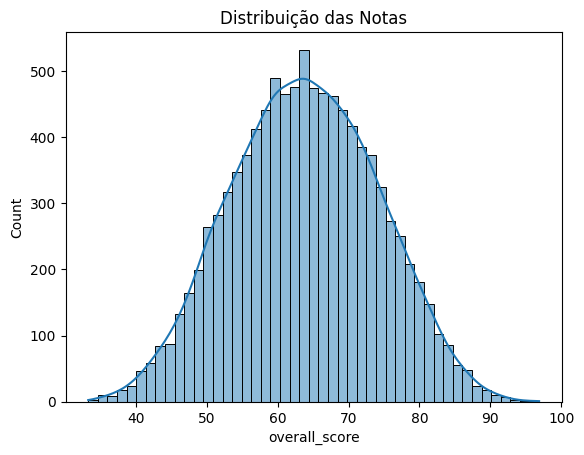

In [14]:
sns.histplot(df['overall_score'], kde=True)
plt.title('Distribuição das Notas')
plt.show()

# Horas de Estudo x Nota

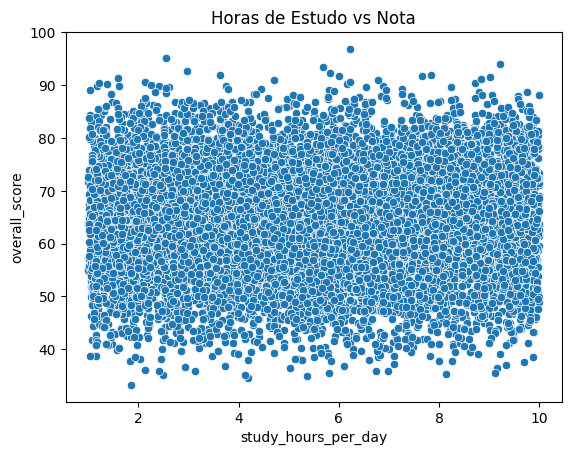

In [19]:
sns.scatterplot(data=df, x='study_hours_per_day', y='overall_score')
plt.title('Horas de Estudo vs Nota')
plt.show()


# Ausência vs Nota

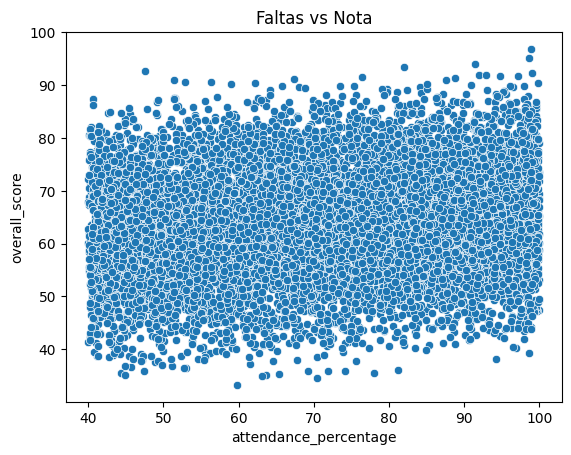

In [20]:
sns.scatterplot(data=df, x='attendance_percentage', y='overall_score')
plt.title('Faltas vs Nota')
plt.show()

# Preparando os Dados para Machine Learning

In [22]:
# Converter Variáveis Categóricas
df = pd.get_dummies(df, drop_first=True)

# Separar X e y
X = df.drop('overall_score', axis=1)
y = df['overall_score']

# Separar treino e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinando o Modelo

In [25]:
# Usando Regressão Linear
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Avaliando o Modelo

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)

rmse = mse**0.5

mae, rmse

(1.2683187833317788e-14, 1.650081571192293e-14)

# Testando um Modelo Avançado

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)